# 03 Data Cleaning

Notebook ini membersihkan 8 dataset berdasarkan hasil analisis di `02_data_assessing.ipynb`.

Langkah cleaning utama:
- Membaca data dari struktur project lokal atau Google Colab. Di Colab, 8 file dataset boleh langsung diletakkan di root/current folder.
- Memisahkan logic cleaning untuk 3 pola data: e-commerce, daily household, dan personal finance.
- Menghapus transaksi yang tidak relevan untuk analisis pengeluaran: order e-commerce `Batal`, amount 0/negatif, dan transaksi non-expense pada dataset finance/household.
- Menyamakan kolom penting: tanggal, amount, kategori, deskripsi, metode pembayaran, lokasi, quantity, dan order id.
- Mengonversi amount ke IDR agar 8 dataset bisa digabung.
- Menangani duplikasi dan outlier amount dengan batas IQR per dataset.
- Menggabungkan hasil akhir menjadi `df_cleaned` dan `df_merged_8_dataset`.


## 1. Import library

Library dibuat sederhana: `pandas` untuk data, `numpy` untuk angka, `matplotlib` untuk visualisasi singkat, dan modul bawaan Python untuk membaca Excel jika engine tambahan tidak tersedia.


In [1]:
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')


## 2. Konfigurasi path lokal dan Google Colab

Cell ini mencari file dataset dari beberapa lokasi. Untuk Google Colab, cukup upload 8 file dataset langsung ke root/current folder, biasanya `/content`.


In [2]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

local_raw_separate_path = project_root / 'data' / 'interim' / 'raw_separate'
local_raw_path = project_root / 'data' / 'raw'
colab_root_path = Path('/content') if Path('/content').exists() else None

candidate_data_paths = [
    local_raw_separate_path,
    project_root,
    local_raw_path,
    local_raw_path / 'Indonesian_Ecommerce_sales',
    local_raw_path / 'daily_household_transaction',
    local_raw_path / 'personal_finance',
]
if colab_root_path is not None and colab_root_path not in candidate_data_paths:
    candidate_data_paths.append(colab_root_path)

candidate_data_paths = list(dict.fromkeys(candidate_data_paths))

interim_path = project_root / 'data' / 'interim'
cleaned_separate_path = interim_path / 'cleaned_separate'
reports_path = project_root / 'reports'

interim_path.mkdir(parents=True, exist_ok=True)
cleaned_separate_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print('Project root       :', project_root)
print('Colab root path    :', colab_root_path)
print('Candidate paths    :')
for path in candidate_data_paths:
    print('-', path)


Project root       : /home/umaygans/05_nayyara_submission_1/nayyara_capstone
Colab root path    : None
Candidate paths    :
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim/raw_separate
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw/Indonesian_Ecommerce_sales
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw/daily_household_transaction
- /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw/personal_finance


## 3. Catalog 8 dataset

Catalog ini berisi nama dataset, domain, periode, dan nama file yang mungkin dipakai. Notebook akan mencari nama CSV hasil data gathering atau nama file raw asli.


In [3]:
DATASET_CATALOG = [
    {
        'dataset_id': 'ecommerce_2024_01_january',
        'dataset_name': 'E-Commerce Sales - January 2024',
        'domain': 'ecommerce_sales',
        'period': '2024-01',
        'possible_files': ['ecommerce_2024_01_january.csv', '01_JanuarySales2024_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2024_06_june',
        'dataset_name': 'E-Commerce Sales - June 2024',
        'domain': 'ecommerce_sales',
        'period': '2024-06',
        'possible_files': ['ecommerce_2024_06_june.csv', '02_JuneSales2024_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2024_12_december',
        'dataset_name': 'E-Commerce Sales - December 2024',
        'domain': 'ecommerce_sales',
        'period': '2024-12',
        'possible_files': ['ecommerce_2024_12_december.csv', '03_DecemberSales2024_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2025_02_february',
        'dataset_name': 'E-Commerce Sales - February 2025',
        'domain': 'ecommerce_sales',
        'period': '2025-02',
        'possible_files': ['ecommerce_2025_02_february.csv', '04_FebruarySales2025_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2025_07_july',
        'dataset_name': 'E-Commerce Sales - July 2025',
        'domain': 'ecommerce_sales',
        'period': '2025-07',
        'possible_files': ['ecommerce_2025_07_july.csv', '05_JulySales2025_clean.xlsx'],
    },
    {
        'dataset_id': 'ecommerce_2025_11_november',
        'dataset_name': 'E-Commerce Sales - November 2025',
        'domain': 'ecommerce_sales',
        'period': '2025-11',
        'possible_files': ['ecommerce_2025_11_november.csv', '06_NovemberSales2025_clean.xlsx'],
    },
    {
        'dataset_id': 'daily_household_transactions',
        'dataset_name': 'Daily Household Transactions',
        'domain': 'household_finance',
        'period': pd.NA,
        'possible_files': ['daily_household_transactions.csv', 'Daily Household Transactions.csv'],
    },
    {
        'dataset_id': 'personal_finance',
        'dataset_name': 'Personal Finance Dataset',
        'domain': 'personal_finance',
        'period': pd.NA,
        'possible_files': ['personal_finance.csv', 'Personal_Finance_Dataset.csv'],
    },
]


def cari_file_dataset(meta, data_paths):
    for data_path in data_paths:
        for file_name in meta['possible_files']:
            file_path = data_path / file_name
            if file_path.exists():
                return file_path

    for data_path in data_paths:
        if not data_path.exists():
            continue
        for file_name in meta['possible_files']:
            matches = [path for path in data_path.rglob(file_name) if '.ipynb_checkpoints' not in str(path)]
            if matches:
                return sorted(matches)[0]
    return None


def path_ringkas(file_path):
    try:
        return str(file_path.relative_to(project_root))
    except ValueError:
        return str(file_path)


dataset_rows = []
missing_files = []

for meta in DATASET_CATALOG:
    file_path = cari_file_dataset(meta, candidate_data_paths)
    if file_path is None:
        missing_files.append(meta['dataset_id'])
        continue

    dataset_rows.append({
        'dataset_id': meta['dataset_id'],
        'dataset_name': meta['dataset_name'],
        'domain': meta['domain'],
        'period': meta['period'],
        'file_name': file_path.name,
        'file_path': file_path,
        'file_path_display': path_ringkas(file_path),
    })

if missing_files:
    raise FileNotFoundError('Dataset belum ditemukan: ' + ', '.join(missing_files))

dataset_files_df = pd.DataFrame(dataset_rows)
display(dataset_files_df.drop(columns='file_path'))


,dataset_id,dataset_name,domain,period,file_name,file_path_display
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,01_JanuarySales2024_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/01_January...
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,02_JuneSales2024_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/02_JuneSal...
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,03_DecemberSales2024_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/03_Decembe...
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,04_FebruarySales2025_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/04_Februar...
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,05_JulySales2025_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/05_JulySal...
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,06_NovemberSales2025_clean.xlsx,data/raw/Indonesian_Ecommerce_sales/06_Novembe...
6,daily_household_transactions,Daily Household Transactions,household_finance,<NA>,Daily Household Transactions.csv,data/raw/daily_household_transaction/Daily Hou...
7,personal_finance,Personal Finance Dataset,personal_finance,<NA>,Personal_Finance_Dataset.csv,data/raw/personal_finance/Personal_Finance_Dat...


## 4. Loader data

Loader ini membaca CSV dan Excel. Jika `pd.read_excel` tidak bisa dipakai karena engine Excel belum tersedia, notebook memakai fallback sederhana dari file `.xlsx`.


In [4]:
def make_unique_columns(columns):
    seen = {}
    unique_columns = []

    for index, column in enumerate(columns):
        column_name = str(column).strip() if pd.notna(column) and str(column).strip() else f'column_{index + 1}'
        if column_name in seen:
            seen[column_name] += 1
            column_name = f'{column_name}_{seen[column_name]}'
        else:
            seen[column_name] = 0
        unique_columns.append(column_name)

    return unique_columns


def excel_column_index(cell_reference):
    letters = ''.join(character for character in str(cell_reference) if character.isalpha()) or 'A'
    index = 0
    for character in letters.upper():
        index = index * 26 + ord(character) - ord('A') + 1
    return index - 1


def read_excel_without_engine(file_path):
    namespace = {'main': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    with ZipFile(file_path) as workbook:
        shared_strings = []
        if 'xl/sharedStrings.xml' in workbook.namelist():
            root = ET.fromstring(workbook.read('xl/sharedStrings.xml'))
            for item in root.findall('main:si', namespace):
                texts = [text.text or '' for text in item.findall('.//main:t', namespace)]
                shared_strings.append(''.join(texts))

        sheet_name = sorted(name for name in workbook.namelist() if name.startswith('xl/worksheets/sheet'))[0]
        root = ET.fromstring(workbook.read(sheet_name))
        rows = []

        for row in root.findall('.//main:row', namespace):
            values = []
            for cell in row.findall('main:c', namespace):
                column_index = excel_column_index(cell.attrib.get('r', 'A1'))
                while len(values) <= column_index:
                    values.append(np.nan)

                cell_type = cell.attrib.get('t')
                value_node = cell.find('main:v', namespace)
                if cell_type == 'inlineStr':
                    texts = [text.text or '' for text in cell.findall('.//main:t', namespace)]
                    value = ''.join(texts) if texts else np.nan
                elif value_node is None:
                    value = np.nan
                elif cell_type == 's':
                    value = shared_strings[int(value_node.text)]
                else:
                    value = value_node.text
                values[column_index] = value
            rows.append(values)

    if not rows:
        return pd.DataFrame()

    max_columns = max(len(row) for row in rows)
    rows = [row + [np.nan] * (max_columns - len(row)) for row in rows]
    return pd.DataFrame(rows[1:], columns=make_unique_columns(rows[0])).replace(r'^\s*$', np.nan, regex=True)


def baca_file_dataset(file_path):
    if file_path.suffix.lower() == '.csv':
        return pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig').replace(r'^\s*$', np.nan, regex=True)
    if file_path.suffix.lower() in ['.xlsx', '.xls']:
        try:
            return pd.read_excel(file_path).replace(r'^\s*$', np.nan, regex=True)
        except ImportError:
            return read_excel_without_engine(file_path)
    raise ValueError(f'Format file belum didukung: {file_path.name}')


def tambah_metadata(frame, row):
    hasil = frame.copy()
    hasil['_dataset_id'] = hasil.get('_dataset_id', row['dataset_id'])
    hasil['_dataset_name'] = hasil.get('_dataset_name', row['dataset_name'])
    hasil['_domain'] = hasil.get('_domain', row['domain'])
    hasil['_dataset_period'] = hasil.get('_dataset_period', row['period'])
    hasil['_source_file'] = hasil.get('_source_file', row['file_name'])
    hasil['_source_path'] = hasil.get('_source_path', row['file_path_display'])
    return hasil


## 5. Load semua dataset raw


In [5]:
raw_datasets = {}
raw_summary_rows = []

for _, row in dataset_files_df.iterrows():
    frame = baca_file_dataset(row['file_path'])
    frame = tambah_metadata(frame, row)
    dataset_id = row['dataset_id']
    raw_datasets[dataset_id] = frame
    raw_summary_rows.append({
        'dataset_id': dataset_id,
        'dataset_name': row['dataset_name'],
        'domain': row['domain'],
        'period': row['period'],
        'source_file': row['file_name'],
        'raw_rows': len(frame),
        'raw_columns': frame.shape[1],
    })

raw_summary_df = pd.DataFrame(raw_summary_rows)
display(raw_summary_df)


,dataset_id,dataset_name,domain,period,source_file,raw_rows,raw_columns
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,01_JanuarySales2024_clean.xlsx,431,24
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,02_JuneSales2024_clean.xlsx,697,24
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,03_DecemberSales2024_clean.xlsx,1214,23
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,04_FebruarySales2025_clean.xlsx,957,24
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,05_JulySales2025_clean.xlsx,766,23
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,06_NovemberSales2025_clean.xlsx,1131,24
6,daily_household_transactions,Daily Household Transactions,household_finance,<NA>,Daily Household Transactions.csv,2461,14
7,personal_finance,Personal Finance Dataset,personal_finance,<NA>,Personal_Finance_Dataset.csv,1500,11


## 6. Helper cleaning umum

Helper ini dipakai bersama oleh semua pola dataset: ambil kolom, ubah angka, ubah tanggal, standarkan kategori, dan hitung IQR.


In [6]:
INR_TO_IDR = 183
USD_TO_IDR = 17_544

FINAL_COLUMNS = [
    'dataset_id', 'dataset_name', 'domain', 'timestamp',
    'amount', 'amount_original', 'amount_before_iqr', 'currency',
    'category', 'category_raw', 'description', 'status',
    'payment_method', 'city', 'province', 'quantity', 'order_id',
    'is_outlier_amount', 'outlier_lower_bound', 'outlier_upper_bound',
]


def ambil_kolom(frame, column_name, default=pd.NA):
    if column_name in frame.columns:
        return frame[column_name]
    return pd.Series(default, index=frame.index)


def bersihkan_teks(series):
    return series.astype('string').str.strip().replace('', pd.NA)


def ubah_ke_angka(series):
    angka = series.astype('string').str.replace(r'[^0-9.\-]', '', regex=True)
    return pd.to_numeric(angka, errors='coerce')


def ubah_ke_tanggal(series):
    return pd.to_datetime(series, errors='coerce', dayfirst=True, format='mixed')


def buat_tanggal_dari_periode(period, index):
    return pd.Series(pd.to_datetime(str(period) + '-01', errors='coerce'), index=index)


def kategori_standar(value, domain):
    text = str(value).lower() if pd.notna(value) else ''

    if domain == 'ecommerce_sales':
        return 'Belanja'
    if any(word in text for word in ['food', 'drink', 'meal', 'snack', 'restaurant', 'groceries']):
        return 'Makanan'
    if any(word in text for word in ['transport', 'travel', 'fuel', 'taxi', 'train']):
        return 'Transportasi'
    if any(word in text for word in ['health', 'fitness', 'medical', 'doctor']):
        return 'Kesehatan'
    if any(word in text for word in ['rent', 'utilities', 'bill', 'subscription']):
        return 'Tagihan'
    if any(word in text for word in ['entertainment', 'movie', 'fun']):
        return 'Hiburan'
    if any(word in text for word in ['education', 'school', 'book']):
        return 'Pendidikan'
    if any(word in text for word in ['shopping', 'apparel', 'household', 'gift']):
        return 'Belanja'
    return 'Lainnya'


def batas_iqr(series):
    angka = pd.to_numeric(series, errors='coerce').dropna()
    if angka.empty:
        return np.nan, np.nan, 0

    q1 = angka.quantile(0.25)
    q3 = angka.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((angka < lower) | (angka > upper)).sum())
    return lower, upper, count


## 7. Cleaning e-commerce

Aturan dari assessing:
- Hapus order `Batal`.
- Hapus amount 0 atau negatif.
- Jika kolom `Waktu Pesanan Dibuat` tidak ada, gunakan tanggal dari periode dataset.
- Kategori distandarkan menjadi `Belanja` karena semua transaksi berasal dari penjualan produk.


In [7]:
def clean_ecommerce(frame, meta):
    data = pd.DataFrame(index=frame.index)
    data['dataset_id'] = meta['dataset_id']
    data['dataset_name'] = meta['dataset_name']
    data['domain'] = meta['domain']

    if 'Waktu Pesanan Dibuat' in frame.columns:
        data['timestamp'] = ubah_ke_tanggal(frame['Waktu Pesanan Dibuat'])
    else:
        data['timestamp'] = buat_tanggal_dari_periode(meta['period'], frame.index)

    data['amount_original'] = ubah_ke_angka(ambil_kolom(frame, 'Total Pembayaran'))
    data['amount'] = data['amount_original']
    data['currency'] = 'IDR'
    data['category_raw'] = bersihkan_teks(ambil_kolom(frame, 'product_categories'))
    data['category'] = 'Belanja'
    data['description'] = bersihkan_teks(ambil_kolom(frame, 'order_id'))
    data['status'] = bersihkan_teks(ambil_kolom(frame, 'Status Pesanan'))
    data['payment_method'] = bersihkan_teks(ambil_kolom(frame, 'Metode Pembayaran'))
    data['city'] = bersihkan_teks(ambil_kolom(frame, 'Kota/Kabupaten'))
    data['province'] = bersihkan_teks(ambil_kolom(frame, 'Provinsi'))
    data['quantity'] = ubah_ke_angka(ambil_kolom(frame, 'total_qty'))
    data['order_id'] = bersihkan_teks(ambil_kolom(frame, 'order_id'))

    data = data[data['status'].str.lower().ne('batal')].copy()
    return data


## 8. Cleaning household dan personal finance

Aturan dari assessing:
- Fokus pada transaksi pengeluaran (`Expense`).
- Samakan amount ke IDR: household dari INR, personal finance dari USD.
- Kategori raw dipetakan ke kategori standar agar bisa dianalisis bersama dataset e-commerce.


In [8]:
def clean_household(frame, meta):
    amount_original = ubah_ke_angka(ambil_kolom(frame, 'Amount'))

    data = pd.DataFrame(index=frame.index)
    data['dataset_id'] = meta['dataset_id']
    data['dataset_name'] = meta['dataset_name']
    data['domain'] = meta['domain']
    data['timestamp'] = ubah_ke_tanggal(ambil_kolom(frame, 'Date'))
    data['amount_original'] = amount_original
    data['amount'] = amount_original * INR_TO_IDR
    data['currency'] = 'INR_TO_IDR'
    data['category_raw'] = bersihkan_teks(ambil_kolom(frame, 'Category'))
    data['category'] = data['category_raw'].map(lambda value: kategori_standar(value, meta['domain']))
    data['description'] = bersihkan_teks(ambil_kolom(frame, 'Note'))
    data['status'] = bersihkan_teks(ambil_kolom(frame, 'Income/Expense'))
    data['payment_method'] = bersihkan_teks(ambil_kolom(frame, 'Mode'))
    data['city'] = pd.NA
    data['province'] = pd.NA
    data['quantity'] = pd.NA
    data['order_id'] = pd.NA

    data = data[data['status'].str.lower().eq('expense')].copy()
    return data


def clean_personal_finance(frame, meta):
    amount_original = ubah_ke_angka(ambil_kolom(frame, 'Amount'))

    data = pd.DataFrame(index=frame.index)
    data['dataset_id'] = meta['dataset_id']
    data['dataset_name'] = meta['dataset_name']
    data['domain'] = meta['domain']
    data['timestamp'] = ubah_ke_tanggal(ambil_kolom(frame, 'Date'))
    data['amount_original'] = amount_original
    data['amount'] = amount_original * USD_TO_IDR
    data['currency'] = 'USD_TO_IDR'
    data['category_raw'] = bersihkan_teks(ambil_kolom(frame, 'Category'))
    data['category'] = data['category_raw'].map(lambda value: kategori_standar(value, meta['domain']))
    data['description'] = bersihkan_teks(ambil_kolom(frame, 'Transaction Description'))
    data['status'] = bersihkan_teks(ambil_kolom(frame, 'Type'))
    data['payment_method'] = pd.NA
    data['city'] = pd.NA
    data['province'] = pd.NA
    data['quantity'] = pd.NA
    data['order_id'] = pd.NA

    data = data[data['status'].str.lower().eq('expense')].copy()
    return data


## 9. Finalisasi cleaning

Tahap ini berlaku untuk semua dataset: buang nilai penting yang kosong, buang amount tidak valid, hapus duplikasi, lalu cap outlier amount memakai batas IQR per dataset.


In [9]:
def finalisasi_cleaning(data, raw_rows):
    before_filter_rows = len(data)

    data = data.dropna(subset=['timestamp', 'amount', 'category']).copy()
    data['amount'] = pd.to_numeric(data['amount'], errors='coerce').astype(float)
    data['amount_original'] = pd.to_numeric(data['amount_original'], errors='coerce').astype(float)
    data = data[data['amount'] > 0].copy()

    duplicate_key = ['timestamp', 'amount', 'category', 'description', 'order_id']
    duplicate_removed = int(data.duplicated(subset=duplicate_key).sum())
    data = data.drop_duplicates(subset=duplicate_key).copy()

    lower, upper, outlier_count = batas_iqr(data['amount'])
    data['amount_before_iqr'] = data['amount']
    data['outlier_lower_bound'] = lower
    data['outlier_upper_bound'] = upper
    data['is_outlier_amount'] = (data['amount'] < lower) | (data['amount'] > upper)

    if pd.notna(upper):
        data['amount'] = data['amount'].clip(lower=max(lower, 0), upper=upper)

    data = data[FINAL_COLUMNS].sort_values('timestamp').reset_index(drop=True)

    summary = {
        'raw_rows': raw_rows,
        'after_status_filter_rows': before_filter_rows,
        'clean_rows': len(data),
        'removed_rows': raw_rows - len(data),
        'duplicate_removed': duplicate_removed,
        'outlier_capped': outlier_count,
        'retention_pct': round(len(data) / raw_rows * 100, 2) if raw_rows else 0,
        'min_date': data['timestamp'].min(),
        'max_date': data['timestamp'].max(),
        'total_amount_idr': data['amount'].sum(),
    }
    return data, summary


def clean_dataset(frame, meta):
    if meta['domain'] == 'ecommerce_sales':
        standard_data = clean_ecommerce(frame, meta)
    elif meta['dataset_id'] == 'daily_household_transactions':
        standard_data = clean_household(frame, meta)
    elif meta['dataset_id'] == 'personal_finance':
        standard_data = clean_personal_finance(frame, meta)
    else:
        raise ValueError(f"Dataset belum dikenali: {meta['dataset_id']}")

    cleaned, summary = finalisasi_cleaning(standard_data, raw_rows=len(frame))
    summary.update({
        'dataset_id': meta['dataset_id'],
        'dataset_name': meta['dataset_name'],
        'domain': meta['domain'],
    })
    return cleaned, summary


## 10. Jalankan cleaning untuk 8 dataset


In [10]:
cleaned_datasets = {}
summary_rows = []

for meta in DATASET_CATALOG:
    dataset_id = meta['dataset_id']
    cleaned, summary = clean_dataset(raw_datasets[dataset_id], meta)
    cleaned_datasets[dataset_id] = cleaned
    summary_rows.append(summary)

cleaning_summary_df = pd.DataFrame(summary_rows)[[
    'dataset_id', 'dataset_name', 'domain', 'raw_rows', 'after_status_filter_rows',
    'clean_rows', 'removed_rows', 'duplicate_removed', 'outlier_capped',
    'retention_pct', 'min_date', 'max_date', 'total_amount_idr'
]]

display(cleaning_summary_df)


,dataset_id,dataset_name,domain,raw_rows,after_status_filter_rows,clean_rows,removed_rows,duplicate_removed,outlier_capped,retention_pct,min_date,max_date,total_amount_idr
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,431,367,367,64,0,28,85.15,2024-01-01 00:05:00,2024-01-31 22:56:00,1.778760e+07
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,697,608,608,89,0,53,87.23,2024-06-01 03:22:00,2024-06-30 23:36:00,2.283769e+07
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,1214,1047,1042,172,0,107,85.83,2024-12-01 00:00:00,2024-12-01 00:00:00,3.392676e+07
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,957,835,831,126,0,106,86.83,2025-02-01 00:40:00,2025-02-28 23:23:00,3.172340e+07
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,766,676,675,91,0,81,88.12,2025-07-01 00:00:00,2025-07-01 00:00:00,2.254522e+07
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,1131,1030,1022,109,0,117,90.36,2025-11-01 06:08:00,2025-11-30 23:17:00,2.892639e+07
6,daily_household_transactions,Daily Household Transactions,household_finance,2461,2176,2157,304,19,368,87.65,2015-01-01 00:00:00,2018-09-20 12:04:08,9.800899e+07
7,personal_finance,Personal Finance Dataset,personal_finance,1500,1222,1222,278,0,0,81.47,2020-01-02 00:00:00,2024-12-29 00:00:00,2.152990e+10


## 11. Validasi hasil cleaning

Validasi dibuat singkat: tidak boleh ada timestamp kosong, amount kosong, amount tidak positif, dan kategori kosong pada hasil akhir.


In [11]:
validation_rows = []

for dataset_id, frame in cleaned_datasets.items():
    validation_rows.append({
        'dataset_id': dataset_id,
        'rows': len(frame),
        'missing_timestamp': int(frame['timestamp'].isna().sum()),
        'missing_amount': int(frame['amount'].isna().sum()),
        'non_positive_amount': int((frame['amount'] <= 0).sum()),
        'missing_category': int(frame['category'].isna().sum()),
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

critical_columns = ['missing_timestamp', 'missing_amount', 'non_positive_amount', 'missing_category']
if validation_df[critical_columns].sum().sum() > 0:
    raise ValueError('Masih ada issue kritis pada hasil cleaning.')

print('Validasi cleaning lolos.')


,dataset_id,rows,missing_timestamp,missing_amount,non_positive_amount,missing_category
0,ecommerce_2024_01_january,367,0,0,0,0
1,ecommerce_2024_06_june,608,0,0,0,0
2,ecommerce_2024_12_december,1042,0,0,0,0
3,ecommerce_2025_02_february,831,0,0,0,0
4,ecommerce_2025_07_july,675,0,0,0,0
5,ecommerce_2025_11_november,1022,0,0,0,0
6,daily_household_transactions,2157,0,0,0,0
7,personal_finance,1222,0,0,0,0


Validasi cleaning lolos.


## 12. Visualisasi singkat hasil cleaning

Visualisasi cukup untuk melihat retensi baris dan distribusi kategori setelah cleaning.


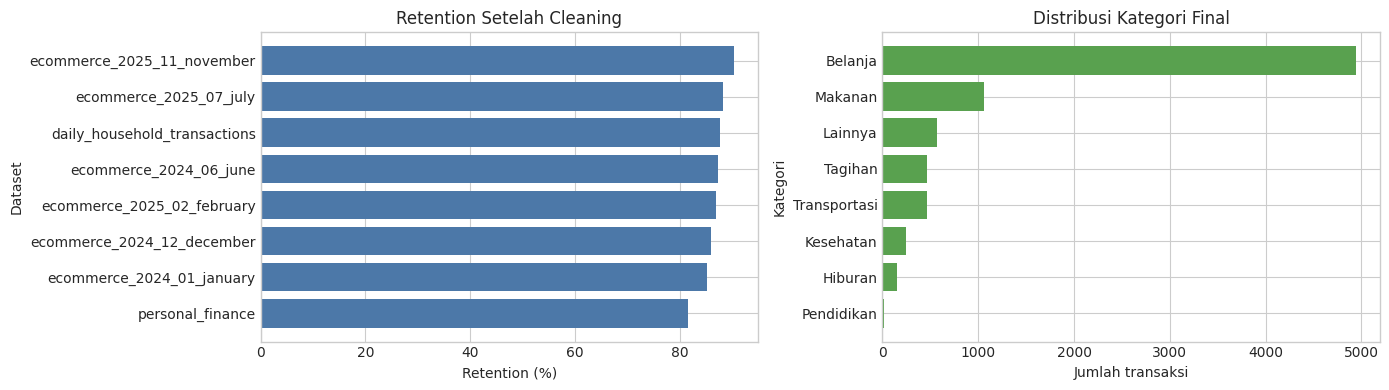

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_retention = cleaning_summary_df.sort_values('retention_pct')
axes[0].barh(plot_retention['dataset_id'], plot_retention['retention_pct'], color='#4c78a8')
axes[0].set_title('Retention Setelah Cleaning')
axes[0].set_xlabel('Retention (%)')
axes[0].set_ylabel('Dataset')

category_summary = (
    pd.concat(cleaned_datasets.values(), ignore_index=True)
    .groupby('category')
    .size()
    .sort_values(ascending=True)
)
axes[1].barh(category_summary.index, category_summary.values, color='#59a14f')
axes[1].set_title('Distribusi Kategori Final')
axes[1].set_xlabel('Jumlah transaksi')
axes[1].set_ylabel('Kategori')

plt.tight_layout()
plt.show()


## 13. Merge 8 dataset clean

Logic merge:
- Setiap dataset sudah dibuat ke struktur kolom yang sama (`FINAL_COLUMNS`).
- `dataset_id`, `dataset_name`, dan `domain` dipertahankan supaya sumber data tetap bisa dianalisis setelah digabung.
- `amount` adalah nominal final dalam IDR setelah konversi mata uang dan treatment outlier IQR.
- `amount_original`, `amount_before_iqr`, dan `currency` tetap disimpan agar perubahan nilai masih bisa ditelusuri.
- Fitur transaksi penting seperti `timestamp`, `category`, `description`, `payment_method`, `city`, `province`, `quantity`, dan `order_id` dipakai karena masuk akal untuk membandingkan pola belanja dari e-commerce, household, dan personal finance.
- Dataset digabung vertikal dengan `pd.concat`, bukan join horizontal, karena 8 dataset berisi transaksi berbeda, bukan record yang perlu dicocokkan satu-satu.


In [13]:
df_merged_8_dataset = pd.concat(cleaned_datasets.values(), ignore_index=True)
df_merged_8_dataset = df_merged_8_dataset.sort_values('timestamp').reset_index(drop=True)

# Alias agar notebook berikutnya bisa tetap memakai nama sederhana.
df_cleaned = df_merged_8_dataset.copy()

print('Jumlah dataset digabungkan:', len(cleaned_datasets))
print('Jumlah baris final:', len(df_merged_8_dataset))

display(df_merged_8_dataset.head())
display(df_merged_8_dataset.groupby('dataset_id').size().reset_index(name='jumlah_baris'))


Jumlah dataset digabungkan: 8
Jumlah baris final: 7924


,dataset_id,dataset_name,domain,timestamp,amount,amount_original,amount_before_iqr,currency,category,category_raw,description,status,payment_method,city,province,quantity,order_id,is_outlier_amount,outlier_lower_bound,outlier_upper_bound
0,daily_household_transactions,Daily Household Transactions,household_finance,2015-01-01,73200.0,400.0,73200.0,INR_TO_IDR,Makanan,Food,bendys chicken biryani,Expense,Credit Card,<NA>,<NA>,<NA>,<NA>,False,-82350.0,151890.0
1,daily_household_transactions,Daily Household Transactions,household_finance,2015-01-01,1830.0,10.0,1830.0,INR_TO_IDR,Transportasi,Transportation,share auto - hospital to brc station,Expense,Cash,<NA>,<NA>,<NA>,<NA>,False,-82350.0,151890.0
2,daily_household_transactions,Daily Household Transactions,household_finance,2015-01-01,3660.0,20.0,3660.0,INR_TO_IDR,Transportasi,Transportation,share auto - Place H to Place T base,Expense,Cash,<NA>,<NA>,<NA>,<NA>,False,-82350.0,151890.0
3,daily_household_transactions,Daily Household Transactions,household_finance,2015-01-01,3660.0,20.0,3660.0,INR_TO_IDR,Transportasi,Transportation,share jeep - Place T base to top,Expense,Cash,<NA>,<NA>,<NA>,<NA>,False,-82350.0,151890.0
4,daily_household_transactions,Daily Household Transactions,household_finance,2015-01-01,36600.0,200.0,36600.0,INR_TO_IDR,Makanan,Food,Temple Prasad,Expense,Cash,<NA>,<NA>,<NA>,<NA>,False,-82350.0,151890.0


,dataset_id,jumlah_baris
0,daily_household_transactions,2157
1,ecommerce_2024_01_january,367
2,ecommerce_2024_06_june,608
3,ecommerce_2024_12_december,1042
4,ecommerce_2025_02_february,831
5,ecommerce_2025_07_july,675
6,ecommerce_2025_11_november,1022
7,personal_finance,1222


## 14. Simpan output cleaning

Output disimpan supaya notebook berikutnya bisa langsung memakai data clean tanpa menjalankan ulang semua proses.


In [14]:
for dataset_id, frame in cleaned_datasets.items():
    frame.to_csv(cleaned_separate_path / f'{dataset_id}_cleaned.csv', index=False)

cleaning_summary_df.to_csv(interim_path / 'cleaning_summary_by_dataset.csv', index=False)
validation_df.to_csv(interim_path / 'cleaning_validation_by_dataset.csv', index=False)
df_merged_8_dataset.to_csv(interim_path / 'cleaned_merged_8_dataset.csv', index=False)

print('Output cleaning tersimpan di:', interim_path)
print('Data siap dipakai: df_cleaned, df_merged_8_dataset, cleaned_datasets, cleaning_summary_df, validation_df')


Output cleaning tersimpan di: /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/interim
Data siap dipakai: df_cleaned, df_merged_8_dataset, cleaned_datasets, cleaning_summary_df, validation_df


## 15. Variabel penting

- `cleaned_datasets`: dictionary hasil cleaning per dataset.
- `cleaning_summary_df`: ringkasan jumlah baris, duplikasi, outlier, dan retention.
- `validation_df`: validasi kualitas hasil cleaning.
- `df_merged_8_dataset`: gabungan final 8 dataset clean.
- `df_cleaned`: alias dari `df_merged_8_dataset` untuk dipakai notebook berikutnya.
